In [1]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import shutil
import yaml
import json

In [3]:
# Prepare training data into YOLO format 
# 1. Convert the bounding box to center coordinates
# 2. Create .txt file for each image
!pip install pycocotools

In [4]:
from pycocotools.coco import COCO

train_ann_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json"
val_ann_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json"
train_images_dir = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
val_images_dir = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"
output_labels_train_dir = "/kaggle/working/dataset/labels/train"
output_labels_val_dir = "/kaggle/working/dataset/labels/val"

# Create output directories
os.makedirs(output_labels_train_dir, exist_ok=True)
os.makedirs(output_labels_val_dir, exist_ok=True)

nc = 5

In [5]:
# Convert bbox coordinates to yolo convention
def convert_bbox_to_yolo(img_w, img_h, bbox):
    x, y, w, h = bbox
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w /= img_w
    h /= img_h
    return x_center, y_center, w, h

In [6]:
def process_coco_annotations(annotation_path, output_labels_dir, images_dir):
    # Initialize COCO API
    coco = COCO(annotation_path)
    
    # Define our target classes
    target_classes = ['person', 'bicycle', 'car', 'bus', 'truck']
    cat_ids = coco.getCatIds(catNms=target_classes)
    
    # Create a mapping from COCO category_id to YOLO class index (0-4)
    # This ensures 'person' is 0, 'bicycle' is 1, etc., regardless of COCO's internal IDs
    coco_id_to_yolo_idx = {coco_id: i for i, coco_id in enumerate(cat_ids)}
    
    # Get all image IDs that contain any of our target classes
    img_ids = set()
    for cat_id in cat_ids:
        class_ids = coco.getImgIds(catIds=[cat_id])
        img_ids.update(class_ids)
    img_ids = list(img_ids)
    
    processed_filenames = []

    print(f"Processing {len(img_ids)} images containing target classes...")

    for img_id in img_ids:
        img_info = coco.loadImgs([img_id])[0]
        img_filename = img_info['file_name']
        img_w, img_h = img_info['width'], img_info['height']
        
        # Check if the image file actually exists before creating a label for it
        if not os.path.exists(os.path.join(images_dir, img_filename)):
            continue

        # Load annotations for this image, filtered by our categories
        ann_ids = coco.getAnnIds(imgIds=[img_id], catIds=cat_ids)
        anns = coco.loadAnns(ann_ids)
        
        if not anns:
            continue

        # Prepare label file path (e.g., 000000000139.txt)
        label_file_name = os.path.splitext(img_filename)[0] + ".txt"
        label_path = os.path.join(output_labels_dir, label_file_name)
        
        valid_labels_found = False
        with open(label_path, 'w') as f:
            for ann in anns:
                if 'bbox' in ann:
                    # COCO bbox is [x_min, y_min, width, height]
                    # Convert to YOLO [x_center, y_center, width, height] normalized
                    yolo_bbox = convert_bbox_to_yolo(img_w, img_h, ann['bbox'])
                    
                    # Map the original COCO category_id to our 0-4 range
                    yolo_class_idx = coco_id_to_yolo_idx[ann['category_id']]
                    
                    line = f"{yolo_class_idx} {' '.join(f'{x:.6f}' for x in yolo_bbox)}\n"
                    f.write(line)
                    valid_labels_found = True
        
        if valid_labels_found:
            processed_filenames.append(img_filename)

    return processed_filenames

In [7]:
# Process both training and validation annotations
train_set = process_coco_annotations(train_ann_path, output_labels_train_dir, train_images_dir)
val_set = process_coco_annotations(val_ann_path, output_labels_val_dir, val_images_dir)

print(f"COCO says there are {len(train_set)} images with your classes.")
print(f"Your script only found {len(val_set)} physical image files.")

loading annotations into memory...
Done (t=17.08s)
creating index...
index created!
Processing 69655 images containing target classes...
loading annotations into memory...
Done (t=0.59s)
creating index...
index created!
Processing 2948 images containing target classes...
COCO says there are 69655 images with your classes.
Your script only found 2948 physical image files.


In [8]:
# Organize dataset in structure suitable for yolov8
import os

train_images_dir = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
val_images_dir = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"
output_train_images_dir = "/kaggle/working/dataset/images/train"
output_val_images_dir = "/kaggle/working/dataset/images/val"

os.makedirs(output_train_images_dir, exist_ok=True)
os.makedirs(output_val_images_dir, exist_ok=True)

print("Organize training images and respective labels")
for img_filename in train_set:
    img_path = os.path.join(train_images_dir, img_filename)
    symlink_path = os.path.join(output_train_images_dir, img_filename)
    if not os.path.exists(symlink_path):
        os.symlink(img_path, symlink_path)

print("Organize validation images and respective labels")
for img_filename in val_set:
    img_path = os.path.join(val_images_dir, img_filename)
    symlink_path = os.path.join(output_val_images_dir, img_filename)
    if not os.path.exists(symlink_path):
        os.symlink(img_path, symlink_path)

for folder in [output_labels_train_dir, output_labels_val_dir]:
    img_folder = folder.replace("labels", "images")
    valid_images = {os.path.splitext(f)[0] for f in os.listdir(img_folder)}
    
    for label_file in os.listdir(folder):
        label_name = os.path.splitext(label_file)[0]
        if label_name not in valid_images:
            os.remove(os.path.join(folder, label_file))

Organize training images and respective labels
Organize validation images and respective labels


In [9]:
# Create data.yaml
data_yaml = """
train: /kaggle/working/dataset/images/train
val: /kaggle/working/dataset/images/val
nc: 5
names:
  0: 'person'
  1: 'bicycle'
  2: 'car'
  3: 'bus'
  4: 'truck'
"""
with open('/kaggle/working/dataset/data.yaml', 'w') as f:
    f.write(data_yaml)

# Model Training

In [10]:
from ultralytics import YOLO

# Load pretrained model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(data='/kaggle/working/dataset/data.yaml', epochs=10, imgsz=640, device=0, workers=4)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

In [11]:
metrics = model.val(data='/kaggle/working/dataset/data.yaml')
print("Validation Results:")
print(metrics)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 114.9±22.7 MB/s, size: 146.5 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 2948 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2948/2948 1.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 185/185 8.9it/s 20.9s
                   all       2948      13952      0.663      0.506      0.562      0.378
                person       2693      11004       0.76      0.657      0.736      0.499
               bicycle        149        316      0.626      0.361      0.402      0.216
                   car        535       1932      0.646      0.524      0.556      0.349
                   bus        189        285      0.744      0.623      0.705      0.568
                 truck        250       

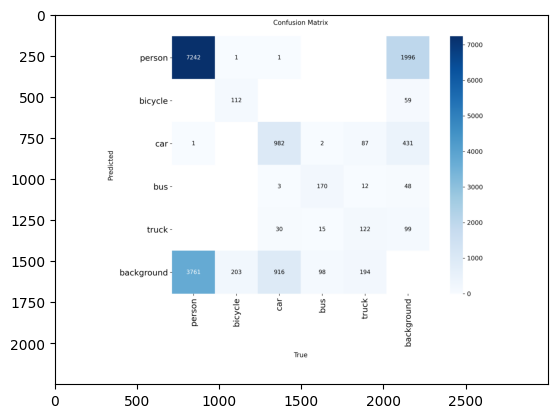

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/working/runs/detect/val/confusion_matrix.png')
imgplot = plt.imshow(img)
plt.show()